In [121]:
%matplotlib inline

# Titanic Survival Prediction

This project uses machine learning to predict passenger survival on the Titanic dataset.

The project covers:
- Data cleaning
- Exploratory Data Analysis (EDA)
- Feature engineering
- Logistic Regression
- Random Forest Classification
- Model evaluation

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [123]:
df = pd.read_csv("C:/Users/HomePC/Desktop/JUPYTER PROJECT/train_and_test2.csv")

# EXPLORATORY DATA ANALYSIS

In [124]:
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [125]:
df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')

In [ ]:
#DATA CLEANING

In [126]:
df = df.drop(columns=[col for col in df.columns if 'zero' in col])

In [127]:
df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass',
       'Embarked', '2urvived'],
      dtype='object')

In [128]:
df.rename(columns={'2urvived' :'survived'}, inplace = True)

In [129]:
df.head()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,survived
0,1,22.0,7.2500,0,1,0,3,2.0,0
1,2,38.0,71.2833,1,1,0,1,0.0,1
2,3,26.0,7.9250,1,0,0,3,2.0,1
3,4,35.0,53.1000,1,1,0,1,2.0,1
4,5,35.0,8.0500,0,0,0,3,2.0,0


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   Parch        1309 non-null   int64  
 6   Pclass       1309 non-null   int64  
 7   Embarked     1307 non-null   float64
 8   survived     1309 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.2 KB


In [131]:
df.describe()

,Passengerid,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,survived
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1307.000000,1309.000000
mean,655.000000,29.503186,33.281086,0.355997,0.498854,0.385027,2.294882,1.492731,0.261268
std,378.020061,12.905241,51.741500,0.478997,1.041658,0.865560,0.837836,0.814626,0.439494
min,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,328.000000,22.000000,7.895800,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000
50%,655.000000,28.000000,14.454200,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000
75%,982.000000,35.000000,31.275000,1.000000,1.000000,0.000000,3.000000,2.000000,1.000000
max,1309.000000,80.000000,512.329200,1.000000,8.000000,9.000000,3.000000,2.000000,1.000000


In [132]:
df.isnull().sum()

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
Parch          0
Pclass         0
Embarked       2
survived       0
dtype: int64

In [133]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [134]:
df.isnull().sum()

Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
Parch          0
Pclass         0
Embarked       0
survived       0
dtype: int64

## Key Insights

- Female passengers had a higher survival rate
- First-class passengers survived more often
- Higher fare correlated with higher survival
- Passengers traveling alone had lower survival rates

# DATA VISUALISATION

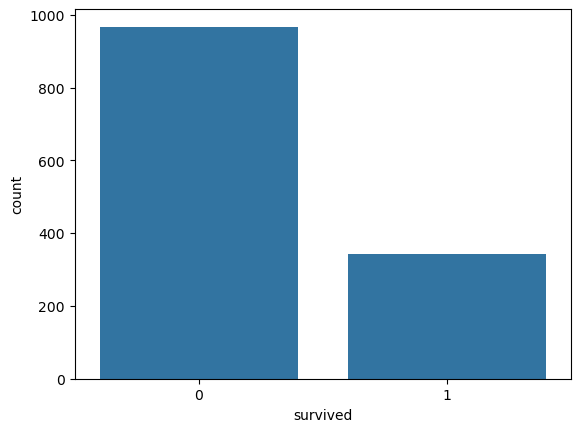

In [135]:
sns.countplot(x='survived', data=df)
plt.show()              

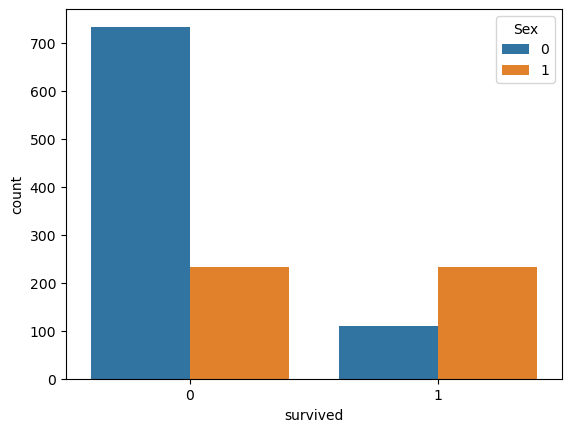

In [136]:
sns.countplot(x='survived', hue='Sex',data = df)
plt.show()

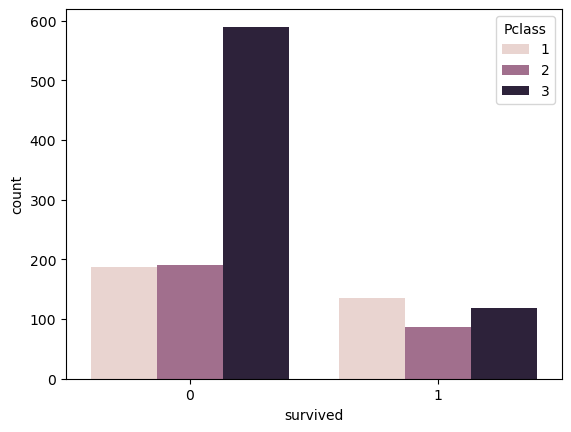

In [137]:
sns.countplot(x='survived',hue='Pclass',data= df)
plt.show()

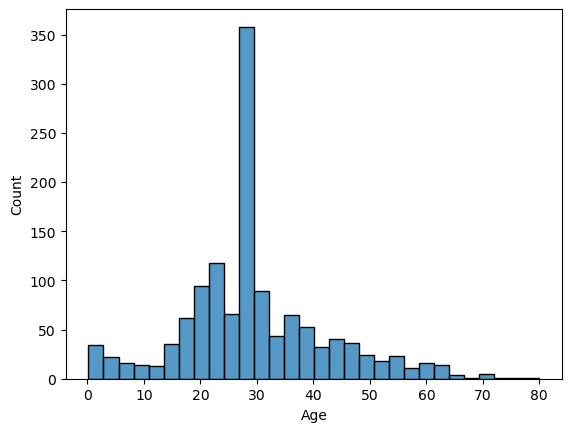

In [138]:
sns.histplot(df['Age'],bins=30)
plt.show()

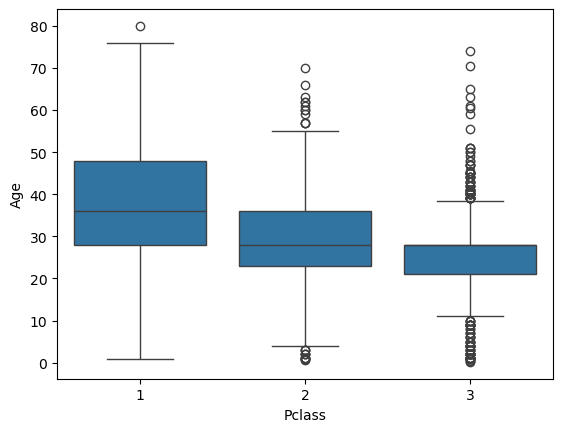

In [139]:
sns.boxplot(x='Pclass',y='Age',data=df)
plt.show()

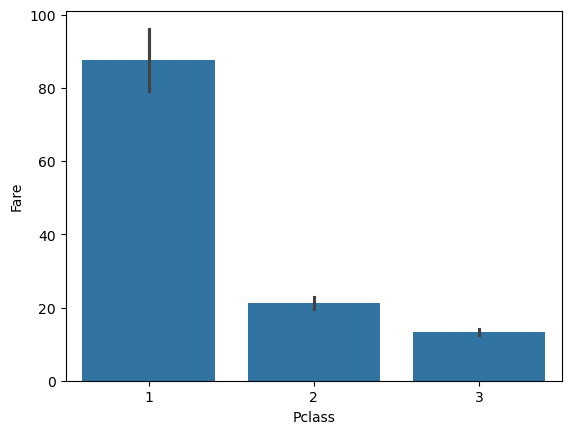

In [140]:
sns.barplot(x='Pclass',y='Fare',data=df)
plt.show()

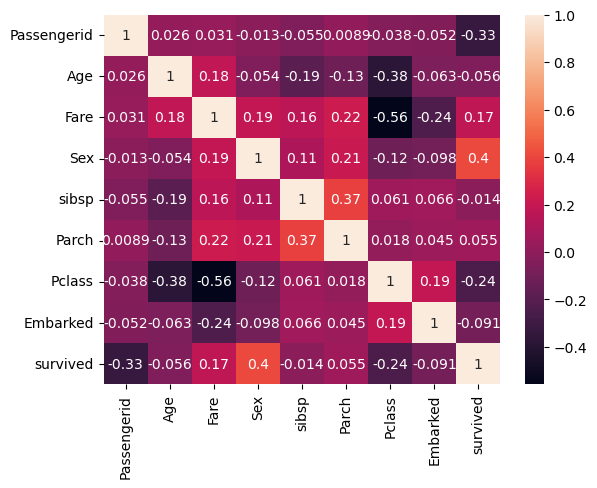

In [141]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)
plt.show()

In [142]:
df = df.drop(columns=[col for col in df.columns if 'Passengerid' in col])

In [ ]:
df.head()

In [144]:
df=pd.get_dummies(df,columns=['Embarked'],drop_first=True)

In [145]:
df.head()

,Age,Fare,Sex,sibsp,Parch,Pclass,survived,Embarked_1.0,Embarked_2.0
0,22.0,7.2500,0,1,0,3,0,False,True
1,38.0,71.2833,1,1,0,1,1,False,False
2,26.0,7.9250,1,0,0,3,1,False,True
3,35.0,53.1000,1,1,0,1,1,False,True
4,35.0,8.0500,0,0,0,3,0,False,True


# FEATURE ENGINEERING

In [146]:
df['FamilySize']=df['sibsp']+ df['Parch']+1
df['IsAlone']=(df['FamilySize']== 1).astype(int)

# MODEL BUILDING

In [147]:
x = df.drop('survived',axis=1)
y = df['survived']

from sklearn.model_selection import train_test_split
x_train ,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [148]:
##from sklearn.linear_model import LogisticRegression
##model = LogisticRegression(max_iter=1000 , class_weight ='balanced')
##model.fit(x_train,y_train)

In [149]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=200,max_depth =5,class_weight ='balanced',random_state=42)
model.fit(x_train,y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [150]:
import pandas as pd 
feature_importance=pd.Series(model.feature_importances_,index=x.columns)
print(feature_importance.sort_values(ascending=False))

Sex             0.392648
Fare            0.188842
Age             0.139483
Pclass          0.117017
FamilySize      0.068697
sibsp           0.034406
Parch           0.023071
Embarked_2.0    0.013978
IsAlone         0.013112
Embarked_1.0    0.008745
dtype: float64


In [151]:
y_pred = model.predict(x_test)

## EVALUATION

In [152]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
print('Accuracy:',accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7595419847328244
[[147  42]
 [ 21  52]]
              precision    recall  f1-score   support

           0       0.88      0.78      0.82       189
           1       0.55      0.71      0.62        73

    accuracy                           0.76       262
   macro avg       0.71      0.75      0.72       262
weighted avg       0.79      0.76      0.77       262

